In [674]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from sklearn.decomposition import PCA 
from sklearn.preprocessing import normalize
from sklearn.datasets import make_classification
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.metrics import accuracy_score
from sklearn.svm import SVC
from sklearn.model_selection import train_test_split 
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# Making a synthetic dataset for the example

In [676]:
# Create dataset

X, y = make_classification(n_samples=500, n_features=20, n_informative=12, n_classes=3, random_state=42) 

In [677]:
# View n x m features

n, m = X.shape

pd.DataFrame(X)

,0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18,19
0,3.298579,-0.585185,0.471382,-0.623951,1.209466,-0.331049,0.606324,0.964674,0.451705,2.775916,2.903429,-3.173599,-0.643314,2.564953,-0.091162,0.164713,-1.723850,-1.545018,0.185498,-4.554678
1,2.869950,-0.206776,2.656664,1.070579,1.041737,2.570456,-1.506089,0.287698,-0.197147,-3.532535,2.106761,0.613614,0.412665,-0.169173,6.152708,-0.450453,-0.085044,3.633439,-0.545817,-1.310041
2,-5.247361,-3.238670,-2.635334,-0.651527,0.734558,0.869002,1.454606,-1.664209,0.233302,-1.712126,-4.314333,1.653597,-0.679936,-1.278205,7.398297,0.410847,0.068598,-6.902217,-0.800009,-2.988880
3,0.254253,0.590645,-0.215373,1.141559,-0.998369,-0.125187,-2.044556,0.136789,-0.359133,-0.077270,0.232516,-2.275591,0.422292,1.496550,-3.030102,3.893424,-1.057704,2.276950,1.101977,-1.264372
4,-3.063435,2.112975,2.483327,1.304066,-0.866673,0.242396,0.051992,-0.892484,-3.116653,-4.152056,-0.020744,2.319051,-1.388510,-1.058373,3.773473,-1.313519,-1.047150,-0.223522,-2.800169,-0.938870
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
495,0.342324,4.005410,-4.472619,0.876213,3.677596,5.980239,-0.248848,1.275373,-0.808189,0.123173,-1.433339,3.703315,-0.256158,-1.627752,10.522075,0.198413,0.308364,-2.501862,-0.325758,0.886710
496,1.686343,-0.326658,5.399543,-0.876394,0.456059,4.692681,-1.270232,-2.063012,1.450087,1.991981,-4.223371,-2.542501,0.862705,-0.417009,-8.138268,7.844848,0.680343,4.742830,0.624580,2.269343
497,-0.981668,-0.346236,-1.768862,1.096543,3.308533,0.178326,-1.931624,1.087454,0.175245,-1.062056,-2.600268,-2.806718,-0.043925,3.873446,-0.204433,-4.034457,-2.013001,-6.330226,-4.105357,-1.382847
498,1.982842,-0.029309,4.205322,-0.754042,3.898171,0.132182,0.123472,0.588911,0.230056,0.038822,-0.349348,1.304182,-0.429776,2.144185,-1.031118,-1.789540,1.944108,-0.771307,-2.057255,-0.399014


In [678]:
# View response vector of length n  

y

array([2, 0, 1, 1, 0, 2, 0, 2, 0, 1, 2, 1, 2, 2, 1, 1, 0, 0, 2, 2, 1, 2,
       2, 2, 2, 2, 0, 1, 1, 0, 2, 1, 0, 0, 0, 2, 2, 0, 2, 0, 1, 2, 2, 0,
       1, 0, 1, 2, 2, 0, 0, 2, 2, 0, 0, 1, 0, 1, 0, 0, 2, 2, 0, 2, 2, 0,
       0, 0, 2, 1, 1, 0, 1, 1, 1, 2, 1, 0, 2, 2, 1, 2, 2, 2, 2, 2, 1, 2,
       1, 1, 0, 2, 1, 1, 1, 0, 1, 0, 0, 0, 0, 2, 1, 0, 1, 1, 1, 0, 0, 0,
       1, 1, 0, 1, 0, 2, 2, 2, 1, 2, 2, 0, 1, 1, 1, 0, 0, 2, 1, 0, 0, 1,
       0, 0, 1, 0, 2, 1, 0, 2, 2, 2, 1, 0, 0, 1, 2, 2, 1, 1, 2, 2, 1, 0,
       2, 2, 1, 2, 0, 1, 2, 2, 1, 2, 0, 2, 0, 1, 0, 0, 0, 1, 1, 0, 0, 2,
       2, 1, 1, 2, 0, 1, 2, 2, 1, 1, 2, 2, 2, 2, 0, 0, 0, 0, 0, 1, 1, 0,
       0, 0, 1, 2, 1, 0, 1, 1, 1, 2, 0, 0, 1, 1, 1, 1, 0, 1, 2, 1, 2, 0,
       1, 1, 1, 0, 0, 2, 0, 2, 1, 2, 1, 2, 2, 2, 2, 0, 0, 2, 0, 2, 2, 0,
       0, 0, 2, 1, 2, 2, 1, 2, 0, 2, 2, 0, 2, 2, 2, 0, 2, 0, 2, 2, 1, 0,
       1, 0, 1, 2, 0, 2, 0, 1, 0, 2, 0, 1, 1, 0, 0, 2, 2, 2, 0, 2, 0, 2,
       2, 0, 2, 1, 0, 2, 2, 1, 2, 2, 2, 0, 0, 1, 1,

# Function for hyperdimensional encoding

In [680]:
def encode_hd(input, dim=1000):

    np.random.seed(42)
    projection = np.random.randn(input.shape[1], dim)
    hypervectors = np.dot(input, projection)

    return np.sign(hypervectors)
    

# Demonstrating the steps of the function

In [682]:
vec_len = 2000

In [683]:
X.shape[1] == m

True

In [684]:
example_projection = np.random.randn(m, vec_len)

In [685]:
pd.DataFrame(example_projection)

,0,1,2,3,4,5,6,7,8,9,...,1990,1991,1992,1993,1994,1995,1996,1997,1998,1999
0,0.098206,-0.064108,0.951791,1.532831,0.686847,1.011544,-0.217404,0.125405,1.485732,0.526711,...,1.017877,0.530883,0.527658,0.483966,1.089595,-0.155406,-1.241556,-0.207220,-1.655624,-1.062057
1,1.619076,-1.100584,-1.173949,0.669622,0.863212,-1.666311,0.248784,-0.548393,0.330577,-0.302673,...,1.002701,-1.450998,1.229158,-0.944927,-0.653632,-1.299738,1.822334,1.186343,1.230662,1.035888
2,0.690742,-0.319692,0.206048,-0.516343,-0.851335,-0.640482,2.354172,-0.382302,1.000776,2.077170,...,0.015865,1.030387,1.800596,0.140149,0.259535,0.954547,1.436756,0.128205,-0.637434,0.866568
3,0.571674,0.856954,0.698742,0.206766,0.264592,0.702245,-1.449527,1.329680,0.449979,-0.846135,...,0.375855,-1.010563,-1.554686,0.876781,-0.980854,-0.181014,0.205551,-0.182420,-1.028036,0.060704
4,0.148025,0.871309,2.444890,-1.976320,-0.798521,0.222942,1.010769,0.346336,1.122993,-1.479820,...,-0.084735,-0.406717,-0.815527,-0.716988,0.533743,-0.701856,-1.099044,0.141010,-2.181973,-0.006398
5,0.078838,0.562897,0.341102,-1.277914,-0.186220,0.652780,0.418040,-0.781870,0.415903,0.914889,...,1.100808,-0.273401,0.451883,-0.463998,-1.426869,0.747872,-1.228324,-0.262254,0.364359,-0.678249
6,1.570363,1.972307,-0.809557,-0.770301,-0.438501,1.153048,0.485934,0.750992,1.315326,-0.905559,...,0.337047,1.944333,1.712456,0.300822,-0.416193,0.381974,-0.324882,-0.640623,0.162859,1.277922
7,-0.189307,-0.201080,-0.264760,0.792637,0.852156,-1.076391,-0.176586,1.106258,-0.334636,1.392499,...,-0.144217,-1.345498,-2.093427,1.095268,1.983908,0.043555,-1.162751,-1.095154,1.181616,0.168944
8,-0.969300,2.299190,1.045412,0.549470,-0.557971,1.238982,0.881888,-0.106493,1.088351,1.045746,...,1.858209,1.117959,1.135706,0.120800,0.231493,-0.921101,-2.672054,0.204387,-0.959520,-0.425084
9,-0.826077,0.324072,-0.199606,1.257387,-0.723189,0.180575,-0.191104,-0.294222,-0.077006,1.520497,...,-0.456636,-0.565212,1.594021,0.625105,-1.329803,-0.451663,0.487646,0.367925,0.527923,-1.486038


In [686]:
example_hypervecs = np.dot(X, example_projection)

In [687]:
pd.DataFrame(example_hypervecs)

,0,1,2,3,4,5,6,7,8,9,...,1990,1991,1992,1993,1994,1995,1996,1997,1998,1999
0,-1.079205,7.277594,-0.159579,23.829613,-2.505632,8.720083,0.834757,1.017002,0.483380,2.488491,...,3.616783,-3.400240,2.454627,8.710692,12.390793,-11.042306,-15.891311,0.592181,-3.118152,-9.520437
1,-6.269448,-1.685566,13.145330,-7.583464,-7.462260,-9.648938,0.458986,-2.454316,1.495887,4.962078,...,2.691221,-13.063881,-16.433018,-1.252246,18.040150,5.297923,-10.041368,0.073751,-10.284984,-2.016167
2,-15.629972,9.398463,3.450560,-25.271387,-8.529689,8.056309,-17.183319,23.048216,-14.666470,-9.613402,...,3.374369,0.460468,-4.666578,3.013306,-5.871895,7.954035,6.950339,-13.081529,-0.529771,-3.230126
3,5.153825,-9.435426,-1.675223,10.884936,4.458581,-2.845262,10.006467,-8.766618,3.704610,-6.818728,...,-3.558135,-6.381212,-15.689082,2.805835,6.744192,1.979269,-0.389182,6.545598,0.920254,5.050836
4,5.932880,-13.533378,-7.837374,-13.266559,2.010691,-9.915038,-1.152581,5.334184,-5.444091,-1.462975,...,-4.779297,-11.940571,-2.651613,-0.146868,-4.616488,2.793453,23.186041,0.720716,4.926910,15.077842
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
495,-13.675017,4.746766,10.752927,-29.948179,-3.065049,-7.956027,-22.441521,12.835709,-2.152823,-5.866502,...,9.132691,-26.879704,-16.408286,-6.521481,-2.724902,4.257150,-4.006353,-5.266769,0.921527,-10.822157
496,16.724370,-10.641011,14.471616,-6.517104,0.302228,5.337262,51.707761,-27.710655,34.203360,8.050843,...,3.877318,17.317680,6.653290,2.057586,-11.990627,20.682485,1.265151,8.205612,-12.709984,12.154369
497,1.935656,8.412507,10.603214,5.300905,-1.167839,23.496376,-13.515237,10.115256,-7.417211,4.810118,...,21.155136,-12.324979,6.112254,13.757823,-20.445350,-15.956045,-2.946830,-7.656492,-8.622326,-8.335192
498,5.448100,10.262896,14.125572,-0.543515,-8.503481,5.427432,14.968932,2.617242,7.159948,18.496795,...,6.737708,2.839972,17.550884,-3.379615,2.318731,-9.015642,0.083300,-2.844021,-17.225942,0.696152


In [688]:
# Apply signum fucnction to vectors

signed_hypervecs = np.sign(example_hypervecs)

In [689]:
pd.DataFrame(signed_hypervecs)

,0,1,2,3,4,5,6,7,8,9,...,1990,1991,1992,1993,1994,1995,1996,1997,1998,1999
0,-1.0,1.0,-1.0,1.0,-1.0,1.0,1.0,1.0,1.0,1.0,...,1.0,-1.0,1.0,1.0,1.0,-1.0,-1.0,1.0,-1.0,-1.0
1,-1.0,-1.0,1.0,-1.0,-1.0,-1.0,1.0,-1.0,1.0,1.0,...,1.0,-1.0,-1.0,-1.0,1.0,1.0,-1.0,1.0,-1.0,-1.0
2,-1.0,1.0,1.0,-1.0,-1.0,1.0,-1.0,1.0,-1.0,-1.0,...,1.0,1.0,-1.0,1.0,-1.0,1.0,1.0,-1.0,-1.0,-1.0
3,1.0,-1.0,-1.0,1.0,1.0,-1.0,1.0,-1.0,1.0,-1.0,...,-1.0,-1.0,-1.0,1.0,1.0,1.0,-1.0,1.0,1.0,1.0
4,1.0,-1.0,-1.0,-1.0,1.0,-1.0,-1.0,1.0,-1.0,-1.0,...,-1.0,-1.0,-1.0,-1.0,-1.0,1.0,1.0,1.0,1.0,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
495,-1.0,1.0,1.0,-1.0,-1.0,-1.0,-1.0,1.0,-1.0,-1.0,...,1.0,-1.0,-1.0,-1.0,-1.0,1.0,-1.0,-1.0,1.0,-1.0
496,1.0,-1.0,1.0,-1.0,1.0,1.0,1.0,-1.0,1.0,1.0,...,1.0,1.0,1.0,1.0,-1.0,1.0,1.0,1.0,-1.0,1.0
497,1.0,1.0,1.0,1.0,-1.0,1.0,-1.0,1.0,-1.0,1.0,...,1.0,-1.0,1.0,1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0
498,1.0,1.0,1.0,-1.0,-1.0,1.0,1.0,1.0,1.0,1.0,...,1.0,1.0,1.0,-1.0,1.0,-1.0,1.0,-1.0,-1.0,1.0


# Generate hypervectors

In [691]:
hypervecs = encode_hd(X, dim=vec_len)

In [692]:
hypervecs.shape

(500, 2000)

In [693]:
hypervecs

array([[ 1., -1.,  1., ..., -1., -1., -1.],
       [ 1.,  1., -1., ..., -1., -1., -1.],
       [-1.,  1.,  1., ...,  1., -1.,  1.],
       ...,
       [-1.,  1.,  1., ..., -1., -1., -1.],
       [-1., -1.,  1., ..., -1.,  1., -1.],
       [ 1.,  1.,  1., ..., -1., -1.,  1.]])

# Concatenate with principal component analysis

In [695]:
pca_mod = PCA(n_components = 10)

In [696]:
components = pca_mod.fit_transform(hypervecs)

In [697]:
pd.DataFrame(components)

,0,1,2,3,4,5,6,7,8,9
0,6.699914,1.124328,-17.412363,15.491746,1.067198,14.045680,-15.279385,1.715752,-6.763150,7.541151
1,-28.443274,4.809226,-11.805177,-1.067081,12.103493,-4.700977,-3.894008,-3.121033,-4.408936,-6.788956
2,-8.908859,-25.679948,10.480754,-3.245593,-2.050478,6.351145,0.716829,13.211353,9.855180,-2.200398
3,12.287995,24.737436,-0.372922,8.026493,5.816823,-6.430017,-14.586561,10.983206,7.490545,3.899603
4,-14.835554,-7.528163,6.247326,-12.143084,5.868072,-11.542377,4.954692,-5.739242,-4.717473,-0.564271
...,...,...,...,...,...,...,...,...,...,...
495,-20.374621,-15.613349,17.024678,10.415580,5.043390,-0.030060,-2.286682,0.945257,-1.600370,-4.991625
496,12.528777,21.304342,-0.203183,3.476532,-7.376840,-12.411924,-11.383085,4.736327,6.373174,-19.791031
497,7.249154,-16.417999,-2.432776,-3.689613,-10.522401,8.265089,4.370968,2.931723,1.680946,10.442951
498,5.263286,1.091583,-11.259096,-14.988269,-7.813875,1.255155,-7.255040,-13.189946,-10.724429,-2.809920


In [698]:
feats = np.hstack((hypervecs, components))

In [699]:
pd.DataFrame(feats)

,0,1,2,3,4,5,6,7,8,9,...,2000,2001,2002,2003,2004,2005,2006,2007,2008,2009
0,1.0,-1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,...,6.699914,1.124328,-17.412363,15.491746,1.067198,14.045680,-15.279385,1.715752,-6.763150,7.541151
1,1.0,1.0,-1.0,1.0,1.0,1.0,-1.0,1.0,1.0,1.0,...,-28.443274,4.809226,-11.805177,-1.067081,12.103493,-4.700977,-3.894008,-3.121033,-4.408936,-6.788956
2,-1.0,1.0,1.0,-1.0,1.0,1.0,1.0,1.0,1.0,-1.0,...,-8.908859,-25.679948,10.480754,-3.245593,-2.050478,6.351145,0.716829,13.211353,9.855180,-2.200398
3,-1.0,-1.0,-1.0,1.0,-1.0,-1.0,-1.0,1.0,1.0,-1.0,...,12.287995,24.737436,-0.372922,8.026493,5.816823,-6.430017,-14.586561,10.983206,7.490545,3.899603
4,-1.0,1.0,-1.0,-1.0,-1.0,1.0,-1.0,-1.0,1.0,-1.0,...,-14.835554,-7.528163,6.247326,-12.143084,5.868072,-11.542377,4.954692,-5.739242,-4.717473,-0.564271
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
495,1.0,1.0,1.0,-1.0,1.0,1.0,1.0,-1.0,1.0,1.0,...,-20.374621,-15.613349,17.024678,10.415580,5.043390,-0.030060,-2.286682,0.945257,-1.600370,-4.991625
496,-1.0,-1.0,-1.0,1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,...,12.528777,21.304342,-0.203183,3.476532,-7.376840,-12.411924,-11.383085,4.736327,6.373174,-19.791031
497,-1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,...,7.249154,-16.417999,-2.432776,-3.689613,-10.522401,8.265089,4.370968,2.931723,1.680946,10.442951
498,-1.0,-1.0,1.0,1.0,1.0,-1.0,-1.0,1.0,-1.0,1.0,...,5.263286,1.091583,-11.259096,-14.988269,-7.813875,1.255155,-7.255040,-13.189946,-10.724429,-2.809920


# Split the data 

In [800]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.4, random_state=42)

In [802]:
pd.DataFrame(X_train)

,0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18,19
0,3.480378,-1.588147,0.715213,-1.007131,0.604329,-1.920820,0.571956,-0.452448,0.372167,-1.995328,2.610961,-3.797434,-0.465873,-1.281654,4.170372,-1.177644,1.723673,-1.984994,0.520652,-3.932185
1,5.574640,1.415385,-0.590889,0.909783,-3.342824,-0.024964,0.594584,0.337087,-1.334454,-0.154952,-5.002176,0.066726,1.531327,1.846527,-10.632719,-1.048462,-0.089664,-4.066601,1.352425,-2.107036
2,-4.635062,-1.816677,-0.177265,-0.665800,1.855260,1.660127,-0.653031,-0.228432,-0.734276,0.744185,-2.800366,0.400738,0.806643,0.411102,3.988527,-1.269155,1.065183,-8.911665,2.054305,-2.892885
3,0.412803,2.465014,0.949221,-1.055386,-0.603391,-1.449643,0.129494,-1.730506,0.753694,1.735439,-0.946587,-1.883181,0.103122,-2.984069,-7.595550,-3.138579,1.799064,-1.157099,0.411438,6.263023
4,1.762522,0.029196,-0.189689,-0.182397,-1.465063,-2.099189,-1.158484,-0.808023,0.072743,2.110466,-1.361852,2.877955,0.239770,1.300948,-4.283401,0.400827,2.024869,-2.138935,-0.273300,-2.980290
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
295,-1.499871,0.122531,1.501435,-1.007994,2.661412,2.830562,-1.900490,1.181563,-0.539398,2.100079,1.291397,2.861615,-0.966882,-1.045691,5.709872,0.752368,0.359854,3.130505,-3.493382,1.803138
296,2.943920,-0.278655,-0.379167,-0.047497,1.026961,0.894499,-0.882560,0.845391,-2.197913,-5.169066,-1.703072,-1.375266,-0.861363,2.409870,1.770633,-0.328448,0.210246,-0.215240,-1.612810,-2.791309
297,5.891803,-0.277785,-1.721487,1.198276,-0.064033,-0.247012,-1.314773,-0.615353,1.484459,3.118609,-2.775799,-1.786862,-2.338428,0.695814,-3.497944,0.524080,-0.017867,-6.386404,-0.844503,-5.358986
298,1.710058,0.660529,4.547350,1.091299,2.173398,-1.974487,0.346052,1.273705,1.054127,-3.354753,-2.468171,-2.315438,1.146182,-3.894308,1.013460,-0.255430,-0.058137,-6.897272,-0.065450,-2.846887


In [804]:
HX_train, HX_test, Hy_train, Hy_test = train_test_split(hypervecs, y, test_size=0.4, random_state=42)

In [806]:
pd.DataFrame(HX_train)

,0,1,2,3,4,5,6,7,8,9,...,1990,1991,1992,1993,1994,1995,1996,1997,1998,1999
0,1.0,1.0,1.0,-1.0,1.0,1.0,1.0,1.0,1.0,1.0,...,-1.0,1.0,1.0,-1.0,1.0,-1.0,-1.0,-1.0,-1.0,-1.0
1,-1.0,-1.0,1.0,1.0,-1.0,-1.0,1.0,1.0,-1.0,-1.0,...,-1.0,-1.0,-1.0,1.0,1.0,1.0,-1.0,1.0,1.0,-1.0
2,-1.0,-1.0,1.0,-1.0,1.0,1.0,1.0,1.0,1.0,1.0,...,-1.0,-1.0,1.0,-1.0,1.0,-1.0,1.0,1.0,-1.0,-1.0
3,-1.0,1.0,-1.0,1.0,-1.0,-1.0,1.0,-1.0,-1.0,-1.0,...,1.0,-1.0,-1.0,1.0,1.0,1.0,-1.0,1.0,1.0,-1.0
4,-1.0,-1.0,1.0,-1.0,-1.0,-1.0,1.0,1.0,-1.0,-1.0,...,1.0,-1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,-1.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
295,1.0,1.0,-1.0,-1.0,1.0,1.0,-1.0,-1.0,-1.0,1.0,...,1.0,1.0,1.0,-1.0,-1.0,-1.0,1.0,-1.0,1.0,-1.0
296,-1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,...,-1.0,1.0,1.0,-1.0,1.0,-1.0,-1.0,-1.0,-1.0,1.0
297,-1.0,-1.0,1.0,-1.0,1.0,1.0,1.0,1.0,1.0,1.0,...,1.0,-1.0,1.0,1.0,1.0,1.0,-1.0,-1.0,1.0,-1.0
298,-1.0,1.0,1.0,1.0,-1.0,1.0,1.0,-1.0,1.0,1.0,...,-1.0,1.0,1.0,1.0,1.0,1.0,1.0,-1.0,-1.0,1.0


In [808]:
FX_train, FX_test, Fy_train, Fy_test = train_test_split(feats, y, test_size=0.4, random_state=42)

In [810]:
pd.DataFrame(FX_train)

,0,1,2,3,4,5,6,7,8,9,...,2000,2001,2002,2003,2004,2005,2006,2007,2008,2009
0,1.0,1.0,1.0,-1.0,1.0,1.0,1.0,1.0,1.0,1.0,...,-9.083538,-9.723406,-23.250674,11.138912,8.840351,1.505987,-0.059315,9.090203,-1.795627,7.998814
1,-1.0,-1.0,1.0,1.0,-1.0,-1.0,1.0,1.0,-1.0,-1.0,...,34.161879,5.536097,-2.819899,2.131423,9.000945,0.331016,4.991161,5.798504,-3.532483,-6.804379
2,-1.0,-1.0,1.0,-1.0,1.0,1.0,1.0,1.0,1.0,1.0,...,2.753134,-30.346262,5.478426,0.049537,-2.010130,9.302998,-6.788352,1.786016,11.940485,-1.997879
3,-1.0,1.0,-1.0,1.0,-1.0,-1.0,1.0,-1.0,-1.0,-1.0,...,23.514370,9.719880,5.388967,9.782929,-7.255205,-6.630300,19.387973,-12.645042,6.442029,-1.899545
4,-1.0,-1.0,1.0,-1.0,-1.0,-1.0,1.0,1.0,-1.0,-1.0,...,28.252163,3.296450,4.506419,-4.629195,7.232577,10.161828,-3.569806,5.433678,-14.032493,0.811860
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
295,1.0,1.0,-1.0,-1.0,1.0,1.0,-1.0,-1.0,-1.0,1.0,...,-28.093464,4.036721,13.543332,2.848807,-9.087610,-0.497426,-4.936847,-8.828716,-6.061892,-6.013802
296,-1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,...,-7.291698,-2.510938,-13.270924,-8.839422,11.080775,-3.370006,-0.842983,14.969440,-0.174235,1.223246
297,-1.0,-1.0,1.0,-1.0,1.0,1.0,1.0,1.0,1.0,1.0,...,23.021425,-7.745176,-7.732348,9.820118,1.877935,6.907423,-3.748937,15.109109,-10.670008,0.102554
298,-1.0,1.0,1.0,1.0,-1.0,1.0,1.0,-1.0,1.0,1.0,...,6.606916,-20.963713,-14.089720,-1.490506,-0.558918,-18.395491,-0.911841,1.323541,-2.651335,-0.069334


In [812]:
PX_train, PX_test, Py_train, Py_test = train_test_split(components, y, test_size=0.4, random_state=42)

In [814]:
pd.DataFrame(PX_train)

,0,1,2,3,4,5,6,7,8,9
0,-9.083538,-9.723406,-23.250674,11.138912,8.840351,1.505987,-0.059315,9.090203,-1.795627,7.998814
1,34.161879,5.536097,-2.819899,2.131423,9.000945,0.331016,4.991161,5.798504,-3.532483,-6.804379
2,2.753134,-30.346262,5.478426,0.049537,-2.010130,9.302998,-6.788352,1.786016,11.940485,-1.997879
3,23.514370,9.719880,5.388967,9.782929,-7.255205,-6.630300,19.387973,-12.645042,6.442029,-1.899545
4,28.252163,3.296450,4.506419,-4.629195,7.232577,10.161828,-3.569806,5.433678,-14.032493,0.811860
...,...,...,...,...,...,...,...,...,...,...
295,-28.093464,4.036721,13.543332,2.848807,-9.087610,-0.497426,-4.936847,-8.828716,-6.061892,-6.013802
296,-7.291698,-2.510938,-13.270924,-8.839422,11.080775,-3.370006,-0.842983,14.969440,-0.174235,1.223246
297,23.021425,-7.745176,-7.732348,9.820118,1.877935,6.907423,-3.748937,15.109109,-10.670008,0.102554
298,6.606916,-20.963713,-14.089720,-1.490506,-0.558918,-18.395491,-0.911841,1.323541,-2.651335,-0.069334


# Test on the non-hypervector features

In [817]:
mod1 = SVC(kernel="linear", random_state=42)
mod1.fit(X_train, y_train)
y_hat1 = mod1.predict(X_test)

In [819]:
accuracy1 = accuracy_score(y_test, y_hat1)

In [821]:
print(accuracy1)

0.605


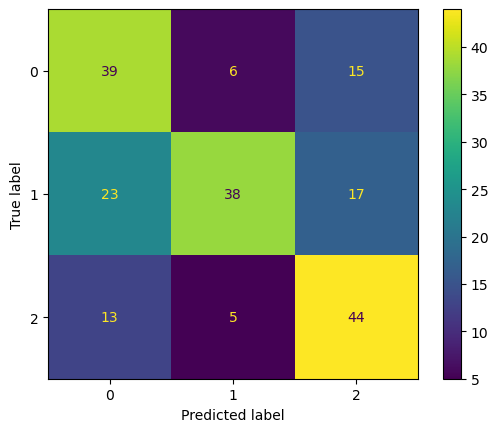

In [823]:
ConfusionMatrixDisplay(confusion_matrix(y_test, y_hat1)).plot()

# Test on the hypervectors alone

In [826]:
mod2 = SVC(kernel="linear", random_state=42)
mod2.fit(HX_train, Hy_train)
y_hat2 = mod2.predict(HX_test)

In [828]:
accuracy2 = accuracy_score(y_test, y_hat2)

In [830]:
print(accuracy2)

0.715


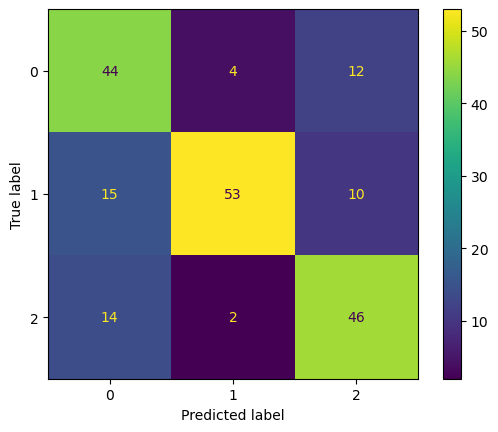

In [832]:
ConfusionMatrixDisplay(confusion_matrix(y_test, y_hat2)).plot()

# Test on expanded hypervector features with PCA

In [835]:
mod3 = SVC(kernel="linear", random_state=42)
mod3.fit(FX_train, Fy_train)
y_hat3 = mod3.predict(FX_test)

In [837]:
accuracy3 = accuracy_score(y_test, y_hat3)

In [839]:
print(accuracy3)

0.71


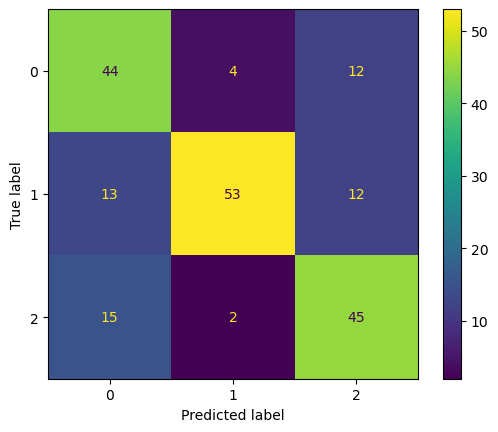

In [841]:
ConfusionMatrixDisplay(confusion_matrix(y_test, y_hat3)).plot()

# Test on just PCA

In [844]:
mod4 = SVC(kernel="linear", random_state=42)
mod4.fit(PX_train, Py_train)
y_hat4 = mod4.predict(PX_test)

In [845]:
accuracy4 = accuracy_score(y_test, y_hat4)

In [848]:
print(accuracy4)

0.6


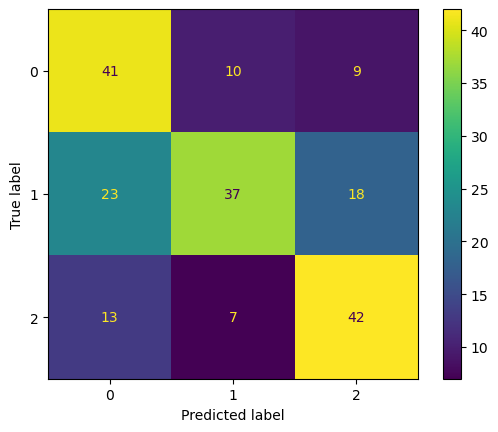

In [850]:
ConfusionMatrixDisplay(confusion_matrix(y_test, y_hat4)).plot()

# Run a sequence of tests over time

In [883]:
def test_func(seed, dim=2000):

    X, y = make_classification(n_samples=500, n_features=20, n_informative=12, n_classes=3, random_state=seed)
    hypervecs = encode_hd(X, dim=dim)

    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.4, random_state=42)
    HX_train, HX_test, Hy_train, Hy_test = train_test_split(hypervecs, y, test_size=0.4, random_state=42)

    mod1 = SVC(kernel="linear", random_state=42)
    mod1.fit(X_train, y_train)
    y_hat1 = mod1.predict(X_test)

    mod2 = SVC(kernel="linear", random_state=42)
    mod2.fit(HX_train, Hy_train)
    y_hat2 = mod2.predict(HX_test)

    return accuracy_score(y_test, y_hat1), accuracy_score(y_test, y_hat2)

In [885]:
scores = []

for _ in range(1,201):
    scores.append(test_func(_))

    

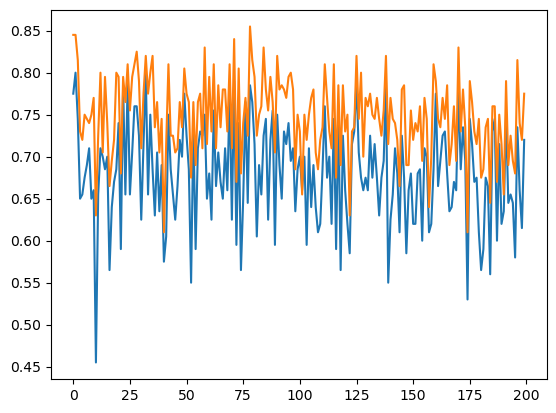

In [886]:
plt.plot([_[0] for _ in scores])
plt.plot([_[1] for _ in scores])

In [887]:
diff = []
wins = []

for _ in scores:
    diff.append(_[1] - _[0])
    if _[1] > _[0]:
        wins.append(1)
    else:
        wins.append(0)

np.mean(diff)

0.06922500000000001

In [888]:
np.sum(wins)/len(wins)

0.99

In [893]:
scores

[(0.775, 0.845),
 (0.8, 0.845),
 (0.745, 0.815),
 (0.65, 0.73),
 (0.655, 0.72),
 (0.675, 0.75),
 (0.69, 0.745),
 (0.71, 0.74),
 (0.65, 0.75),
 (0.66, 0.77),
 (0.455, 0.63),
 (0.655, 0.725),
 (0.71, 0.8),
 (0.7, 0.705),
 (0.685, 0.795),
 (0.7, 0.74),
 (0.565, 0.665),
 (0.64, 0.695),
 (0.67, 0.72),
 (0.685, 0.8),
 (0.74, 0.795),
 (0.59, 0.68),
 (0.785, 0.795),
 (0.655, 0.765),
 (0.79, 0.81),
 (0.655, 0.755),
 (0.705, 0.795),
 (0.76, 0.81),
 (0.76, 0.825),
 (0.725, 0.79),
 (0.625, 0.71),
 (0.715, 0.775),
 (0.8, 0.82),
 (0.655, 0.775),
 (0.75, 0.8),
 (0.685, 0.82),
 (0.63, 0.735),
 (0.705, 0.765),
 (0.635, 0.705),
 (0.69, 0.745),
 (0.575, 0.61),
 (0.605, 0.715),
 (0.75, 0.81),
 (0.685, 0.725),
 (0.655, 0.725),
 (0.625, 0.705),
 (0.665, 0.71),
 (0.72, 0.765),
 (0.7, 0.735),
 (0.775, 0.805),
 (0.725, 0.775),
 (0.685, 0.765),
 (0.55, 0.675),
 (0.735, 0.765),
 (0.59, 0.69),
 (0.71, 0.765),
 (0.73, 0.775),
 (0.725, 0.71),
 (0.75, 0.83),
 (0.65, 0.715),
 (0.68, 0.795),
 (0.625, 0.73),
 (0.755, 0